# Medical VQA

 - **Dataset**: VQA-RAD
 - **Model**: Qwen3-vl-8b-instruct

# 0. Dependency installation

In [1]:
!pip install -q -U unsloth trl deepeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.1/824.1 kB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 174.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/Fine-Tuning/Prism'

Mounted at /content/drive
/content/drive/MyDrive/Fine-Tuning/Prism


# 1. Load and Explore VQA

In [3]:
from datasets import load_dataset

dataset = load_dataset("flaviagiammarino/vqa-rad")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-eb8844602202be(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e5bc3d208bb4dee(…):   0%|          | 0.00/10.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1793 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/451 [00:00<?, ? examples/s]

In [4]:
print(f"Train: {len(dataset['train'])} examples")
print(f"Test: {len(dataset['test'])} examples")
print(f"\nColumns: {dataset['train'].column_names}")
print("\nFirst example:")
print(f"\tQuestion: {dataset['train'][0]['question']}")
print(f"\tAnswer: {dataset['train'][0]['answer']}")

Train: 1793 examples
Test: 451 examples

Columns: ['image', 'question', 'answer']

First example:
	Question: are regions of the brain infarcted?
	Answer: yes


In [5]:
import collections

def classify_answer_type(answer):
  return "CLOSED" if answer.strip().lower() in ("yes", "no") else "OPEN"

# answer type distribution
train_types = collections.Counter(classify_answer_type(ex['answer']) for ex in dataset['train'])
test_types = collections.Counter(classify_answer_type(ex['answer']) for ex in dataset['test'])

print("Answer type distribution:")
print(f"\tTrain - CLOSED (yes/no): {train_types['CLOSED']}, OPEN: {train_types['OPEN']}")
print(f"\tTest - CLOSED (yes/no): {test_types['CLOSED']}, OPEN: {test_types['OPEN']}")

# answer length distribution for OPEN questions
open_answers = [ex['answer'] for ex in dataset['train'] if classify_answer_type(ex['answer']) == 'OPEN']
lengths = [len(a.split()) for a in open_answers]
print(f"\nOpen answer length (words): min={min(lengths)}, median={sorted(lengths)[len(lengths) // 2]}, max={max(lengths)}")

print("\nSample CLOSED questions:")
for ex in dataset['train']:
    if classify_answer_type(ex['answer']) == 'CLOSED':
        print(f"\tQuestion: {ex['question']}")
        print(f"\tAnswer: {ex['answer']}", end="\n")
        break

print("\nSample OPEN questions:")
for ex in dataset['train']:
    if classify_answer_type(ex['answer']) == 'OPEN':
        print(f"\tQuestion: {ex['question']}")
        print(f"\tAnswer: {ex['answer']}", end="\n")

Answer type distribution:
	Train - CLOSED (yes/no): 940, OPEN: 853
	Test - CLOSED (yes/no): 251, OPEN: 200

Open answer length (words): min=1, median=2, max=17

Sample CLOSED questions:
	Question: are regions of the brain infarcted?
	Answer: yes

Sample OPEN questions:
	Question: which organ system is abnormal in this image?
	Answer: cardiovascular
	Question: how was this image taken?
	Answer: mri
	Question: what is the condition of the patient
	Answer: blind loop syndrome
	Question: what abnormality is seen?
	Answer: blind-ending loop of bowel arising from the cecum
	Question: what is the location of the mass?
	Answer: pineal region
	Question: where is the mass?
	Answer: pineal region
	Question: in which lobe are the lesions?
	Answer: bilateral frontal lobes
	Question: where are the lesions?
	Answer: bilateral frontal lobes
	Question: what type of image is this?
	Answer: mri-dwi
	Question: what is the location of the abnormality?
	Answer: right colon
	Question: where is the abnormal f

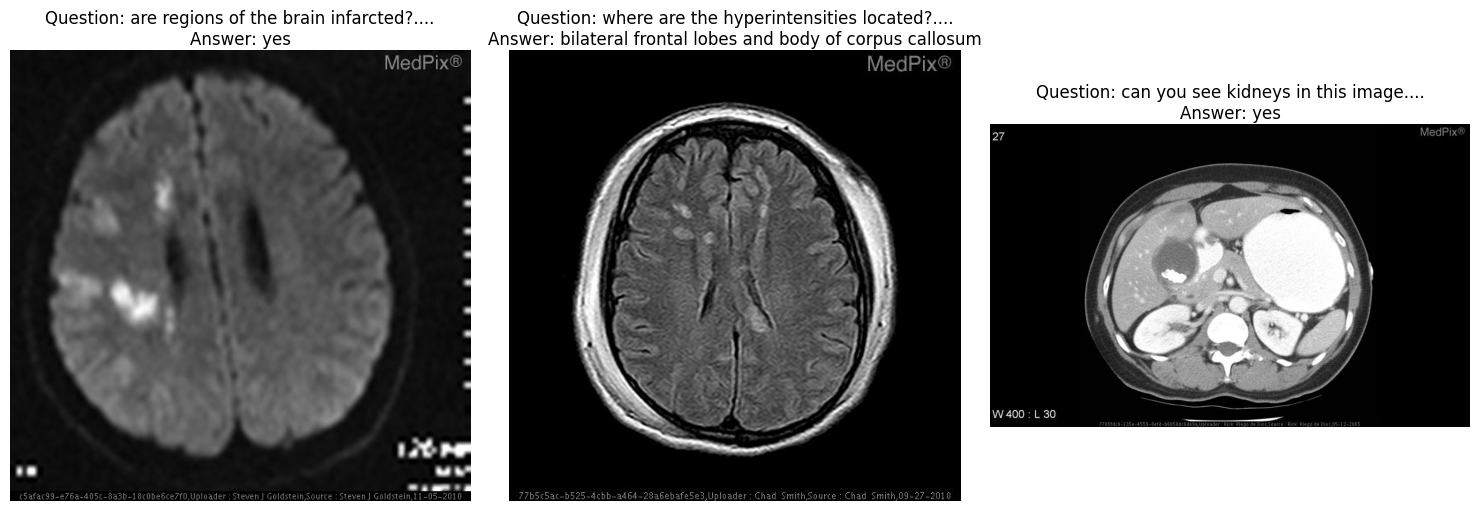

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    ex = dataset['train'][i * 50]
    ax.imshow(ex['image'])
    ax.set_title(f"Question: {ex['question']}....\nAnswer: {ex['answer']}", fontsize=12, wrap=True)
    ax.axis('off')
plt.tight_layout()
plt.show()

# 2. Format Dataset for VLM Training

In [7]:
# System Prompt
SYSTEM_PROMPT = (
    """You are an expert radiologist assistant. Analyze the provided medical image and answer the question accurately and concisely based on what you observe."""
)

def format_vqa_example(example):
    """Convert a VQA-RAD example into Unsloth's conversation format."""
    return {
        "messages": [
            {
                "role": "system",
                "content": [{"type": "text", "text": SYSTEM_PROMPT}],
            },
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": example["image"]},
                    {"type": "text", "text": example["question"]},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": example["answer"]}],
            },
        ]
    }

train_data = [format_vqa_example(ex) for ex in dataset['train']]
test_data = [format_vqa_example(ex) for ex in dataset['test']]

print(f"Formatted {len(train_data)} training examples")
print(f"Formatted {len(dataset)} test examples")
print("\nSample formatted example:")
for msg in train_data[0]['messages']:
    content_types = [item['type'] for item in msg['content']]
    print(f"\t[{msg['role']}] content types: {content_types}")

Formatted 1793 training examples
Formatted 2 test examples

Sample formatted example:
	[system] content types: ['text']
	[user] content types: ['image', 'text']
	[assistant] content types: ['text']


# 3. Load Model and Apply LoRA

In [8]:
from unsloth import FastVisionModel
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [15]:
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
    load_in_4bit=True,
    use_gradient_checkpointing=True,
)

print(f"Model loaded: {type(model).__name__}")

==((====))==  Unsloth 2026.2.1: Fast Qwen3_Vl patching. Transformers: 4.57.6.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded: Qwen3VLForConditionalGeneration


In [16]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=128,
    lora_alpha=256,
    lora_dropout=0,
    bias="none",
    random_state=47,
    use_rslora=False,
    loftq_config=None,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
vision_trainable = sum(p.numel() for n, p in model.named_parameters() if 'visual' in n and p.requires_grad)

print(f"Trainable: {trainable/1e6:.1f}M / {total/1e6:.1f}M ({trainable/total*100:.2f}%)")
print(f"Vision encoder trainable: {vision_trainable} (should be 0)")

Trainable: 349.2M / 5802.8M (6.02%)
Vision encoder trainable: 0 (should be 0)


# 4. Baseline Evaluation

In [11]:
!pip install -q qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 65.9 MB/s eta 0:00:00


In [13]:
from qwen_vl_utils import process_vision_info

def generate_answer(model, tokenizer, image, question, max_tokens=64):
    """Run inference on one or more image+question pairs.

    Returns:
        str for single input, list[str] for batched input.
    """
    image_is_batch = isinstance(image, (list, tuple))
    question_is_batch = isinstance(question, (list, tuple))
    single_input = not image_is_batch and not question_is_batch

    images = list(image) if image_is_batch else [image]
    questions = list(question) if question_is_batch else [question] * len(images)

    if len(images) != len(questions):
        raise ValueError("image and question must have the same length")
    if not images:
        return "" if single_input else []

    messages_batch = [
        [
            {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": img},
                    {"type": "text", "text": q},
                ],
            },
        ]
        for img, q in zip(images, questions)
    ]

    input_texts = []
    image_inputs = []
    video_inputs = []
    has_any_video = False

    for messages in messages_batch:
        input_texts.append(
            tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        )

        imgs, vids = process_vision_info(messages)
        if imgs is not None:
            image_inputs.extend(imgs)
        if vids is not None:
            video_inputs.extend(vids)
            has_any_video = True

    tokenizer_kwargs = {
        "text": input_texts,
        "images": image_inputs,
        "padding": True,
        "return_tensors": "pt",
    }
    if has_any_video:
        tokenizer_kwargs["videos"] = video_inputs

    inputs = tokenizer(**tokenizer_kwargs).to(model.device)

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=0.1,
            do_sample=False,
        )

    prompt_lengths = inputs["attention_mask"].sum(dim=1).tolist()
    predictions = [
        tokenizer.decode(
            output_ids[i][int(prompt_lengths[i]):],
            skip_special_tokens=True,
        ).strip()
        for i in range(len(input_texts))
    ]

    return predictions[0] if single_input else predictions

In [14]:
import random

random.seed(47)
N_EVAL = 100
eval_indices = random.sample(range(len(dataset['test'])), min(N_EVAL, len(dataset['test'])))
eval_subset = [dataset['test'][i] for i in eval_indices]

print(f"Running baseline evaluation on {len(eval_subset)} test examples....")

FastVisionModel.for_inference(model)

baseline_results = []
for i, ex in enumerate(eval_subset):
    pred = generate_answer(model, tokenizer, ex['image'], ex['question'])
    baseline_results.append({
        'question': ex['question'],
        'answer': ex['answer'],
        'prediction': pred,
        'answer_type': classify_answer_type(ex['answer']),
    })
    if (i + 1) % 20 == 0:
        print(f"\t{i+1}/{len(eval_subset)} done!")

print("\nBaseline evaluation Completed!!")

Running baseline evaluation on 100 test examples....
	20/100 done!
	40/100 done!
	60/100 done!
	80/100 done!
	100/100 done!

Baseline evaluation Completed!!


In [17]:
def compute_vqa_metrics(results):
    """Compute CLOSED accuracy and OPEN token-F1/exact match in one pass."""
    if not results:
        return {
            "closed_accuracy": 0.0,
            "closed_count": 0,
            "open_token_f1": 0.0,
            "open_exact_match": 0.0,
            "open_count": 0,
        }

    def normalize(text):
        return " ".join(str(text).lower().strip().split())

    closed_total = 0
    closed_correct = 0
    open_total = 0
    open_exact = 0
    open_f1_sum = 0.0

    for r in results:
        answer_type = r.get("answer_type")
        pred_norm = normalize(r.get("prediction", ""))
        ans_norm = normalize(r.get("answer", ""))

        if answer_type == "CLOSED":
            closed_total += 1
            if pred_norm == ans_norm:
                closed_correct += 1
            continue

        if answer_type == "OPEN":
            open_total += 1

            if pred_norm == ans_norm:
                open_exact += 1
                open_f1_sum += 1.0
                continue

            pred_tokens = set(pred_norm.split())
            ans_tokens = set(ans_norm.split())
            if not pred_tokens or not ans_tokens:
                continue

            common = pred_tokens & ans_tokens
            if not common:
                continue

            precision = len(common) / len(pred_tokens)
            recall = len(common) / len(ans_tokens)
            open_f1_sum += 2 * precision * recall / (precision + recall)

    return {
        "closed_accuracy": closed_correct / closed_total if closed_total else 0.0,
        "closed_count": closed_total,
        "open_token_f1": open_f1_sum / open_total if open_total else 0.0,
        "open_exact_match": open_exact / open_total if open_total else 0.0,
        "open_count": open_total,
    }


In [18]:
baseline_metrics = compute_vqa_metrics(baseline_results)
print("Baseline (zero-shot) performance.")
print(f"\tCLOSED (yes/no) accuracy: {baseline_metrics['closed_accuracy']:.1f} (n={baseline_metrics['closed_count']})")
print(f"\tOPEN exact match:         {baseline_metrics['open_exact_match']:.1f} (n={baseline_metrics['open_count']})")
print(f"\tOPEN token F1:            {baseline_metrics['open_token_f1']:.3f}")

Baseline (zero-shot) performance.
	CLOSED (yes/no) accuracy: 0.1 (n=56)
	OPEN exact match:         0.0 (n=44)
	OPEN token F1:            0.041


In [19]:
# Analyzing where model is failing
print("Sample baseline predictions:\n")
for r in baseline_results[:8]:
    status = "CORRECT" if r['prediction'].lower().strip().startswith(r['answer'].lower().strip()) else "INCORRECT"
    print(f"\t[{r['answer_type']}] {status}")
    print(f"\tQ: {r['question']}")
    print(f"\tGold: {r['answer']}")
    print(f"\tPred: {r['prediction'][:100]}")
    print("-"*30)

Sample baseline predictions:

	[CLOSED] CORRECT
	Q: does the liver show an enhancing mass or lesion?
	Gold: no
	Pred: No, the liver does not show an enhancing mass or lesion in this CT scan.

**Explanation:**
- The liv
------------------------------
	[OPEN] CORRECT
	Q: is this supratentorial or infratentorial?
	Gold: supratentorial
	Pred: Supratentorial.

This is an axial MRI slice of the brain showing the cerebral hemispheres above the 
------------------------------
	[CLOSED] CORRECT
	Q: is anything not normal in the image?
	Gold: yes
	Pred: Yes, there is something not normal in the image.

This is a CT scan of the abdomen, and the most pro
------------------------------
	[CLOSED] CORRECT
	Q: is pneumo intestinalis present?
	Gold: yes
	Pred: Yes, pneumo intestinalis is present.

**Explanation:**
The CT image shows multiple areas of air (low
------------------------------
	[OPEN] INCORRECT
	Q: what two tributaries of blood vessels are impacted?
	Gold: left aca and mca
	Pred: Based on 

#### Explanation of Above results:
 - **It can be seen that model is little more verbose that the expected answers.**

# 5. Training Model

In [20]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

In [21]:
FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=train_data,
    args=SFTConfig(
        per_device_train_batch_size=4,
        gradient_accumulation_steps=6,
        warmup_steps=10,
        num_train_epochs=3,
        learning_rate=2e-4,
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="cosine",
        seed=47,
        output_dir="outputs/vqa-rad-qwen3-vl-8b-instruct-lora",
        report_to="none",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        remove_unused_columns=False,
        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},
        max_seq_length=2048,
    ),
)

print("Trainer initialized!")

Unsloth: Model does not have a default image size - using 512
Trainer initialized!


In [22]:
trainer_stats = trainer.train()

print("\nTraining Complete!")
print(f"\tTotal Steps: {trainer_stats.global_step}")
print(f"\tFinal Loss: {trainer_stats.training_loss:.4f}")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,793 | Num Epochs = 3 | Total steps = 225
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 6
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 6 x 1) = 24
 "-____-"     Trainable parameters = 349,175,808 of 9,116,299,504 (3.83% trained)


Step,Training Loss
10,1.659200
20,0.466100
30,0.389900
40,0.373900
50,0.364300
60,0.373900
70,0.352700
80,0.308000
90,0.288200
100,0.275600



Training Complete!
	Total Steps: 225
	Final Loss: 0.3331


In [23]:
if torch.cuda.is_available():
    peak = torch.cuda.max_memory_allocated() / 1e9
    current = torch.cuda.memory_allocated() / 1e9
    total_gpu = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Peak memory during training: {peak:.1f} GB / {total_gpu:.1f} GB")
    print(f"Current memory: {current:.1f} GB")

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Peak memory during training: 15.9 GB / 102.0 GB
Current memory: 9.9 GB


# 6. Save Model

In [24]:
import gc
import torch

SAVE_DIR = "./model/Qwen3-vl-8b-instruct-medical-vqa-v2"
ADAPTER_DIR = SAVE_DIR + "-lora"
BASE_MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"

def _clear_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

saved_merged = False

# 1) Fast path: merge directly from the in-memory PEFT model.
try:
    merged_model = model.merge_and_unload()
    merged_model.save_pretrained(
        SAVE_DIR,
        safe_serialization=True,
        max_shard_size="2GB",
    )
    tokenizer.save_pretrained(SAVE_DIR)
    saved_merged = True
    print(f"Saved merged model to {SAVE_DIR}")

except Exception as e:
    print(f"Direct merge_and_unload() failed: {e}")

    # 2) Always save adapters so training output is not lost.
    model.save_pretrained(ADAPTER_DIR, safe_serialization=True)
    tokenizer.save_pretrained(ADAPTER_DIR)
    print(f"Saved LoRA adapter checkpoint to {ADAPTER_DIR}")

    # 3) Best-effort retry: reload full-precision base, apply LoRA, then merge.
    try:
        from peft import PeftModel
        from unsloth import FastVisionModel

        _clear_vram()
        base_model, _ = FastVisionModel.from_pretrained(
            BASE_MODEL_ID,
            load_in_4bit=False,
            use_gradient_checkpointing=False,
        )
        base_with_lora = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
        merged_model = base_with_lora.merge_and_unload()

        merged_model.save_pretrained(
            SAVE_DIR,
            safe_serialization=True,
            max_shard_size="2GB",
        )
        tokenizer.save_pretrained(SAVE_DIR)
        saved_merged = True
        print(f"Saved merged model to {SAVE_DIR} (adapter applied to base and merged).")

    except Exception as e2:
        print("Could not create merged checkpoint in this runtime.")
        print(f"You can still use adapter-only checkpoint at: {ADAPTER_DIR}")
        print(f"Merge retry error: {e2}")

if saved_merged:
    print("Final artifact: merged model safetensors + tokenizer.")
else:
    print("Final artifact: adapter safetensors + tokenizer (merge can be done later).")

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


Saved merged model to ./model/Qwen3-vl-8b-instruct-medical-vqa-v2
Final artifact: merged model safetensors + tokenizer.


# 7. Post Training Evaluation

In [ ]:
import os
import gc
import torch

SAVE_DIR = "./model/Qwen3_VL_32B_DocVQA"
ADAPTER_DIR = SAVE_DIR + "-lora"
BASE_MODEL_ID = "Qwen/Qwen3-VL-32B-Instruct"  # required if adapter-only load

# ---------- Save ----------
saved_path = None
try:
    merged_model = model.merge_and_unload()
    merged_model.save_pretrained(
        SAVE_DIR,
        safe_serialization=True,
        max_shard_size="4GB",
    )
    tokenizer.save_pretrained(SAVE_DIR)
    saved_path = SAVE_DIR
    print(f"Saved merged model to: {SAVE_DIR}")
except Exception as e:
    print(f"merge_and_unload failed: {e}")
    model.save_pretrained(ADAPTER_DIR, safe_serialization=True)
    tokenizer.save_pretrained(ADAPTER_DIR)
    saved_path = ADAPTER_DIR
    print(f"Saved adapter-only checkpoint to: {ADAPTER_DIR}")

# Free memory before reload
for var_name in ["merged_model", "model"]:
    if var_name in globals():
        del globals()[var_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ---------- Load ----------
def load_saved_vlm(path, base_model_id=None, load_in_4bit=True):
    # Adapter-only checkpoint
    if os.path.exists(os.path.join(path, "adapter_config.json")):
        if base_model_id is None:
            raise ValueError("base_model_id is required to load adapter-only checkpoints.")
        from unsloth import FastVisionModel
        from peft import PeftModel

        base_model, tok = FastVisionModel.from_pretrained(
            model_name=base_model_id,
            load_in_4bit=load_in_4bit,
            use_gradient_checkpointing=False,
        )
        model_loaded = PeftModel.from_pretrained(base_model, path, is_trainable=False)
        FastVisionModel.for_inference(model_loaded)
        return model_loaded, tok, "adapter"

    # Merged/full checkpoint
    from transformers import AutoProcessor
    try:
        from transformers import AutoModelForImageTextToText as AutoVLM
    except Exception:
        from transformers import AutoModelForVision2Seq as AutoVLM

    tok = AutoProcessor.from_pretrained(path, trust_remote_code=True)
    model_loaded = AutoVLM.from_pretrained(
        path,
        trust_remote_code=True,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto",
        low_cpu_mem_usage=True,
    )
    model_loaded.eval()
    return model_loaded, tok, "merged"

model, tokenizer, ckpt_type = load_saved_vlm(
    saved_path,
    base_model_id=BASE_MODEL_ID,
    load_in_4bit=True,  # only used for adapter-only load
)

print(f"Reloaded {ckpt_type} checkpoint from: {saved_path}")

In [25]:
FastVisionModel.for_inference(model)

print(f"Running fine-tuned evaluation on {len(eval_subset)} test examples...")

finetuned_results = []
for i, ex in enumerate(eval_subset):
    pred = generate_answer(model, tokenizer, ex['image'], ex['question'])
    finetuned_results.append({
        'question': ex['question'],
        'answer': ex['answer'],
        'prediction': pred,
        'answer_type': classify_answer_type(ex['answer']),
    })
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(eval_subset)} done")

finetuned_metrics = compute_vqa_metrics(finetuned_results)

print("\nFine-tuned performance:")
print(f"  CLOSED (yes/no) accuracy:  {finetuned_metrics['closed_accuracy']:.1%}")
print(f"  OPEN exact match:          {finetuned_metrics['open_exact_match']:.1%}")
print(f"  OPEN token F1:             {finetuned_metrics['open_token_f1']:.3f}")

Running fine-tuned evaluation on 100 test examples...
  20/100 done
  40/100 done
  60/100 done
  80/100 done
  100/100 done

Fine-tuned performance:
  CLOSED (yes/no) accuracy:  73.2%
  OPEN exact match:          15.9%
  OPEN token F1:             0.281


In [26]:
print("="*60)
print("BASELINE vs FINE-TUNED")
print("="*60)
print(f"{'Metric':<30} {'Baseline':>12} {'Fine-tuned':>12} {'Delta':>10}")
print("-"*65)

comparisons = [
    ("CLOSED accuracy", baseline_metrics['closed_accuracy'], finetuned_metrics['closed_accuracy']),
    ("OPEN exact match", baseline_metrics['open_exact_match'], finetuned_metrics['open_exact_match']),
    ("OPEN token F1", baseline_metrics['open_token_f1'], finetuned_metrics['open_token_f1']),
]

for name, base, ft in comparisons:
    delta = ft - base
    arrow = "↑" if delta > 0 else "↓" if delta < 0 else "→"
    print(f"{name:<30} {base:>11.1%} {ft:>11.1%} {arrow} {abs(delta):>8.1%}")

BASELINE vs FINE-TUNED
Metric                             Baseline   Fine-tuned      Delta
-----------------------------------------------------------------
CLOSED accuracy                       7.1%       73.2% ↑    66.1%
OPEN exact match                      0.0%       15.9% ↑    15.9%
OPEN token F1                         4.1%       28.1% ↑    24.0%


#### After Training Evaluation:
 - **After only training 0.7% of training weights the accuracy has drastically increased from 7.1% to 73.2% that is 66.1% increase.**
 - **For F1 it increased by 24% which means the verboseness of the model has reduced and it answers to an expected length as per the target output which also means F1 can be a reliable metrics in this trial run**

# 8. LLM-AS-JUDGE Evaluation

In [27]:
!uv pip install -q -U python-dotenv

In [28]:
import os
from dotenv import load_dotenv
load_dotenv()
try:
  os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")  # Required for DeepEval LLM-as-Judge
  print("OPENAI_API_KEY loaded successfully!")
except Exception:
  print("Error Loading OPENAI_API_KEY!")

OPENAI_API_KEY loaded successfully!


In [29]:
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams

In [32]:
medical_correctness = GEval(
    name="Medical VQA Correctness",
    criteria=(
        """Evaluate Whether the predicted answer to a radiology question is medically correct when compared to the reference answer. Consider:
        1) Are the key clinical findings the same?
        2) Is the anatomical location correct?
        3) Is the diagnosis or observation equivalent, even if phrased differently?"""
    ),
    evaluation_params=[
        LLMTestCaseParams.INPUT,
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.EXPECTED_OUTPUT,
    ],
    model="gpt-4o-mini",
    threshold=0.6,
)

In [33]:
open_results = [r for r in finetuned_results if r['answer_type'] == 'OPEN']

eval_open = open_results[:30]
print(f"Running GEval on {len(eval_open)} open-ended predictions....")

geval_scores = []
for r in eval_open:
  test_case = LLMTestCase(
      input=r['question'],
      actual_output=r['prediction'],
      expected_output=r['answer'],
  )
  medical_correctness.measure(test_case)
  geval_scores.append(medical_correctness.score)

avg_score = sum(geval_scores) / len(geval_scores)
passing = sum(1 for s in geval_scores if s >= 0.6) / len(geval_scores)
print("\nGEval Medical Correctness:")
print(f"\tAverage score: {avg_score:.3f}")
print(f"\tPass rate (>=0.6): {passing:.1f}")

Output()

Running GEval on 30 open-ended predictions....


Output()

Output()

Output()

...

Output()

Output()

Output()

Output()


GEval Medical Correctness:
	Average score: 0.345
	Pass rate (>=0.6): 0.2


# 9. Error Analysis

In [34]:
print("CLOSED question failures (wrong yes/no):\n")
closed_failures = [
    r for r in finetuned_results
    if r['answer_type'] == 'CLOSED'
    and not r['prediction'].lower().strip().startswith(r['answer'].lower().strip())
]
for r in closed_failures[:5]:
  print(f"\tQuestion: {r['question']}")
  print(f"\tGold: {r['answer']}  |  Prediction: {r['prediction'][:50]}", end="\n")

print(f"Total CLOSED failures: {len(closed_failures)} / {finetuned_metrics['closed_count']}")

CLOSED question failures (wrong yes/no):

	Question: is there fat stranding?
	Gold: no  |  Prediction: yes
	Question: is there hylar lymphadenopathy?
	Gold: yes  |  Prediction: no
	Question: is there evidence of an aortic aneurysm?
	Gold: yes  |  Prediction: no
	Question: is the left lung field more radioopaque than the right side?
	Gold: yes  |  Prediction: no
	Question: is the right hemidiaphragm normal?
	Gold: no  |  Prediction: yes
Total CLOSED failures: 15 / 56


In [35]:
# Verbosity check
open_results_ft = [r for r in finetuned_results if r['answer_type'] == 'OPEN']

pred_lengths = [len(r['prediction'].split()) for r in open_results_ft]
gold_lengths = [len(r['answer'].split()) for r in open_results_ft]

avg_pred = sum(pred_lengths) / len(pred_lengths) if pred_lengths else 0
avg_gold = sum(gold_lengths) / len(gold_lengths) if gold_lengths else 0

print("OPEN answer verbosity:")
print(f"\tGold avg length: {avg_gold:.1f} words")
print(f"\tPred avg length: {avg_pred:.1f} words")
print(f"\tRatio (pred/gold): {avg_pred/avg_gold:.2f}x" if avg_gold > 0 else "")

if avg_pred > avg_gold * 2:
  print("\t\t Model is significantly more verbose than refernce answers")
  print("\t F1 is inflated and precision is lowered")

OPEN answer verbosity:
	Gold avg length: 2.6 words
	Pred avg length: 2.2 words
	Ratio (pred/gold): 0.82x


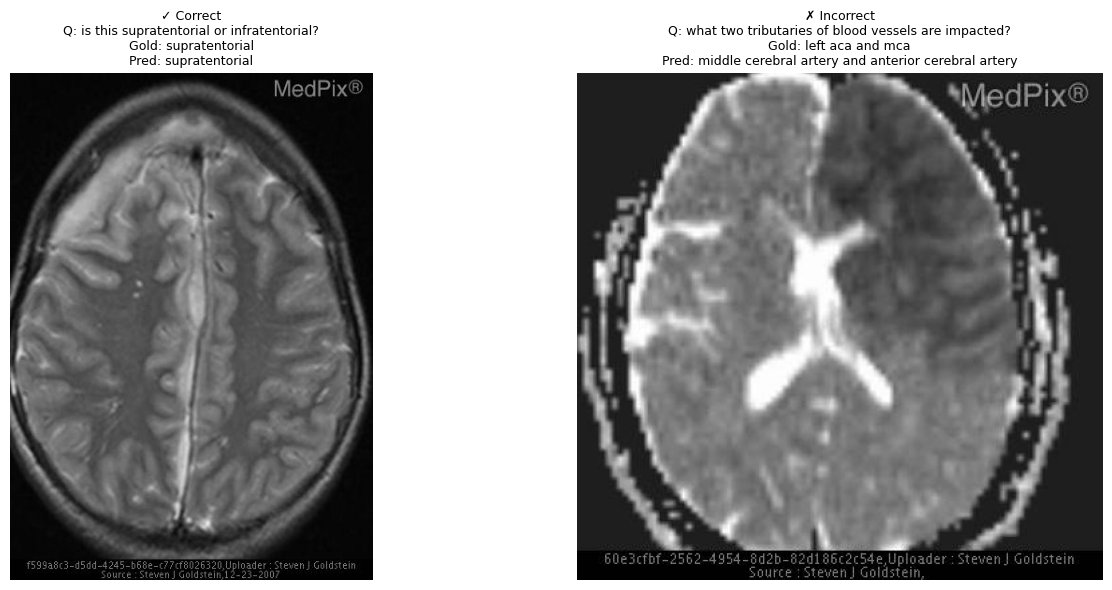

In [36]:
import matplotlib.pyplot as plt

# Find a success and a failure
successes = [i for i, r in enumerate(finetuned_results) if r['answer_type'] == 'OPEN'
             and r['prediction'].lower().strip() == r['answer'].lower().strip()]
failures = [i for i, r in enumerate(finetuned_results) if r['answer_type'] == 'OPEN'
            and r['prediction'].lower().strip() != r['answer'].lower().strip()]

examples_to_show = []
if successes:
    examples_to_show.append((successes[0], "✓ Correct"))
if failures:
    examples_to_show.append((failures[0], "✗ Incorrect"))

if examples_to_show:
    fig, axes = plt.subplots(1, len(examples_to_show), figsize=(7 * len(examples_to_show), 6))
    if len(examples_to_show) == 1:
        axes = [axes]
    for ax, (idx, label) in zip(axes, examples_to_show):
        ax.imshow(eval_subset[idx]['image'])
        r = finetuned_results[idx]
        ax.set_title(
            f"{label}\nQ: {r['question'][:60]}\nGold: {r['answer']}\nPred: {r['prediction'][:60]}",
            fontsize=9,
        )
        ax.axis('off')
    plt.tight_layout()
    plt.show()